In [1]:
import geopandas as gpd
from dem_stitcher.geojson_io import read_geojson_gzip
from rasterio.crs import CRS
import matplotlib.pyplot as plt
import contextily as ctx
import pandas as pd
from shapely import STRtree
from tqdm import tqdm
import numpy as np

# Natural Earth

In [2]:
# land_url = 'https://raw.githubusercontent.com/martynafford/natural-earth-geojson/refs/heads/master/10m/physical/ne_10m_land.json'
# df_ne_land = gpd.read_file(land_url)

In [3]:
# minor_islands_url = 'https://raw.githubusercontent.com/martynafford/natural-earth-geojson/refs/heads/master/10m/physical/ne_10m_minor_islands.json'
# df_ne_mi = gpd.read_file(minor_islands_url)

In [4]:
# df_ne_all_land = pd.concat([df_ne_mi, df_ne_land])
# land_geo = df_ne_all_land.geometry.unary_union

# MGRS

In [5]:
df_mgrs = gpd.read_parquet('../N_hls_tiles/mgrs.parquet')
df_mgrs = df_mgrs.rename(columns={'tile_id': 'mgrs_tile_id'})
print('Total MGRS tiles: ', df_mgrs.shape[0])
df_mgrs.head()

Total MGRS tiles:  56686


,mgrs_tile_id,epsg,utm_wkt,geometry
0,01CCV,32701,"MULTIPOLYGON(((300000 2000020,300000 1890220,4...","MULTIPOLYGON (((-179.62744 -72.08140, -179.775..."
1,01CDH,32701,"MULTIPOLYGON(((399960 800020,399960 690220,509...","MULTIPOLYGON (((-176.29744 -82.85185, -176.185..."
2,01CDJ,32701,"MULTIPOLYGON(((399960 900040,399960 790240,509...","MULTIPOLYGON (((-176.37525 -81.95591, -176.288..."
3,01CDK,32701,"MULTIPOLYGON(((399960 1000000,399960 890200,50...","MULTIPOLYGON (((-176.43739 -81.06046, -176.368..."
4,01CDL,32701,"MULTIPOLYGON(((399960 1100020,399960 990220,50...","MULTIPOLYGON (((-176.48820 -80.16441, -176.431..."


In [6]:
# %%time
# tree = STRtree(df_mgrs.geometry)
# idxs_land = tree.query(land_geo, predicate="intersects")

In [7]:
with open('dist_hls_tiles.txt') as f:
    hls_tiles = f.readlines()
hls_tiles = list(map(lambda tile: tile.strip(), hls_tiles))
hls_tiles[:3]

['01RGJ', '01RFL', '01REL']

In [8]:
idxs_dist = df_mgrs.mgrs_tile_id.isin(hls_tiles)
idxs_dist[:3]

0    False
1    False
2    False
Name: mgrs_tile_id, dtype: bool

In [9]:
df_mgrs_dist_hls = df_mgrs[idxs_dist].reset_index(drop=True)
n = df_mgrs_dist_hls.shape[0]
f'Total MGRS tiles over land: {n}'

'Total MGRS tiles over land: 19043'

<Axes: >

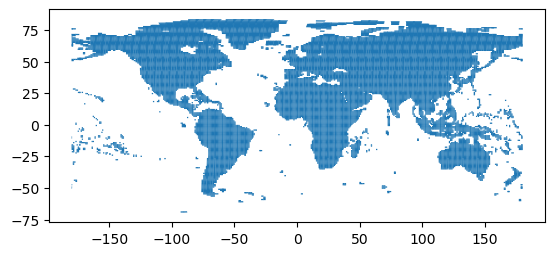

In [10]:
df_mgrs_dist_hls.plot()

# JPL Bursts

In [11]:
df_burst = read_geojson_gzip('../A_download_burst_data/opera_burst_ids.geojson.zip')
# Maybe I may have duplicated rows with burst? Not sure, but drop duplicates ensures we have 1 row for each jpl_burst_id
df_burst = df_burst.drop_duplicates(subset='burst_id_jpl', keep='first').reset_index(drop=True)
df_burst.head()

,geometry,burst_id_jpl,is_land,is_north_america,orbit_pass
0,"POLYGON ((2.53190 4.75701, 3.29631 4.91201, 3....",t001_000025_iw1,1,False,ASCENDING
1,"POLYGON ((3.25912 4.97460, 4.06055 5.13657, 4....",t001_000025_iw2,1,False,ASCENDING
2,"POLYGON ((4.02659 5.18854, 4.73485 5.32978, 4....",t001_000025_iw3,1,False,ASCENDING
3,"POLYGON ((2.49611 4.92361, 3.26087 5.07851, 3....",t001_000026_iw1,1,False,ASCENDING
4,"POLYGON ((3.22392 5.14115, 4.02565 5.30297, 3....",t001_000026_iw2,1,False,ASCENDING


In [12]:
burst_geos = df_burst.geometry.tolist()
burst_id = df_burst.burst_id_jpl.str.upper().str.replace('_', '-').tolist()
track_number = df_burst.burst_id_jpl.map(lambda burst_id: int(burst_id.split('_')[0][1:]))
orbit_pass = df_burst.orbit_pass.tolist()

In [13]:
df_burst_final = gpd.GeoDataFrame({'jpl_burst_id': burst_id,
                                   'orbit_pass': orbit_pass,
                                   'track_number': track_number,
                                   #'is_land': df_burst.is_land.tolist()
                                  },
                                   geometry=burst_geos,
                                   crs=CRS.from_epsg(4326))
df_burst_final.head()

,jpl_burst_id,orbit_pass,track_number,geometry
0,T001-000025-IW1,ASCENDING,1,"POLYGON ((2.53190 4.75701, 3.29631 4.91201, 3...."
1,T001-000025-IW2,ASCENDING,1,"POLYGON ((3.25912 4.97460, 4.06055 5.13657, 4...."
2,T001-000025-IW3,ASCENDING,1,"POLYGON ((4.02659 5.18854, 4.73485 5.32978, 4...."
3,T001-000026-IW1,ASCENDING,1,"POLYGON ((2.49611 4.92361, 3.26087 5.07851, 3...."
4,T001-000026-IW2,ASCENDING,1,"POLYGON ((3.22392 5.14115, 4.02565 5.30297, 3...."


# Serialize MGRS and Burst Data

In [14]:
df_burst_final.to_parquet('jpl_burst.parquet', compression='zstd')
df_mgrs_dist_hls.to_parquet('mgrs.parquet', compression='zstd')

# Multipolygons along Antimeridian

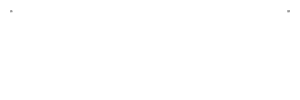

In [15]:
multi_geo = df_burst_final[df_burst_final.jpl_burst_id == 'T008-015335-IW1'].geometry.values[0]
multi_geo

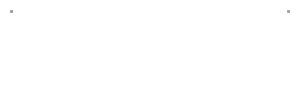

In [16]:
anti_meridian_tile_id = '01VCK'
df_mgrs[df_mgrs.mgrs_tile_id == anti_meridian_tile_id].geometry.values[0]

# Spatial Join

Note we could have change `how='inner'` and removed the `na` accounting. But we wanted to see which HLS tiles were missing.

In [17]:
%%time

df_mgrs_burst = gpd.sjoin(df_mgrs_dist_hls, df_burst_final, how='left', predicate='intersects')
df_mgrs_burst = df_mgrs_burst.drop(columns='index_right').reset_index(drop=True)
df_mgrs_burst.head()

CPU times: user 1.19 s, sys: 100 ms, total: 1.29 s
Wall time: 1.29 s


,mgrs_tile_id,epsg,utm_wkt,geometry,jpl_burst_id,orbit_pass,track_number
0,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T058-123817-IW2,DESCENDING,58.0
1,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T058-123816-IW2,DESCENDING,58.0
2,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T154-330467-IW3,ASCENDING,154.0
3,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T058-123815-IW2,DESCENDING,58.0
4,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T081-173673-IW1,ASCENDING,81.0


In [18]:
df_mgrs_burst[df_mgrs_burst.mgrs_tile_id == '01XDE']

,mgrs_tile_id,epsg,utm_wkt,geometry,jpl_burst_id,orbit_pass,track_number
5839,01XDE,32601,"MULTIPOLYGON(((399960 8500020,399960 8390220,5...","MULTIPOLYGON (((-176.62325 76.58075, -176.6484...",NaN,NaN,NaN


In [19]:
df_mgrs_burst_f = df_mgrs_burst.dropna(subset=['jpl_burst_id']).reset_index(drop=True)
df_mgrs_burst_f.shape, df_mgrs_burst.shape

((1126910, 7), (1126924, 7))

We can explore the tiles that are in HLS but do not intersect with JPL Bursts.

In [20]:
f'Total MGRS tiles that do not intesect with jpl bursts: {df_mgrs_burst.jpl_burst_id.isnull().sum()}'

'Total MGRS tiles that do not intesect with jpl bursts: 14'

In [21]:
df_mgrs_burst[df_mgrs_burst.jpl_burst_id.isnull()]#.explore()

,mgrs_tile_id,epsg,utm_wkt,geometry,jpl_burst_id,orbit_pass,track_number
5839,01XDE,32601,"MULTIPOLYGON(((399960 8500020,399960 8390220,5...","MULTIPOLYGON (((-176.62325 76.58075, -176.6484...",NaN,NaN,NaN
68449,11RPH,32611,"MULTIPOLYGON(((600000 2800020,600000 2690220,7...","POLYGON ((-116.00651 25.31339, -116.01439 24.3...",NaN,NaN,NaN
359479,23EMN,32723,"MULTIPOLYGON(((399960 3300040,399960 3190240,5...","POLYGON ((-46.81698 -60.42353, -46.87396 -61.4...",NaN,NaN,NaN
359480,23EMP,32723,"MULTIPOLYGON(((399960 3400000,399960 3290200,5...","POLYGON ((-46.76847 -59.52640, -46.82192 -60.5...",NaN,NaN,NaN
359481,23ENN,32723,"MULTIPOLYGON(((499980 3300040,499980 3190240,6...","POLYGON ((-45.00036 -60.43592, -45.00037 -61.4...",NaN,NaN,NaN
399833,26VMN,32626,"MULTIPOLYGON(((399960 6800040,399960 6690240,5...","POLYGON ((-28.86875 61.32159, -28.81212 60.336...",NaN,NaN,NaN
399837,26VPM,32626,"MULTIPOLYGON(((600000 6700020,600000 6590220,7...","POLYGON ((-25.18372 60.42408, -25.23682 59.438...",NaN,NaN,NaN
399838,26VPN,32626,"MULTIPOLYGON(((600000 6800040,600000 6690240,7...","POLYGON ((-25.13199 61.32160, -25.18860 60.336...",NaN,NaN,NaN
407551,27VUG,32627,"MULTIPOLYGON(((300000 6700020,300000 6590220,4...","POLYGON ((-24.62936 60.38699, -24.52346 59.402...",NaN,NaN,NaN
407552,27VUH,32627,"MULTIPOLYGON(((300000 6800040,300000 6690240,4...","POLYGON ((-24.73250 61.28313, -24.61963 60.299...",NaN,NaN,NaN


# Visualization/Explanation

## Looking at Burst Coverage over MGRS tiles - Known Edge Cases

### Lots of Tracks

In [22]:
tile_id_large_num_tracks = '48XVP' #df_mgrs_burst.mgrs_tile_id.sample(n=1, random_state=3).values[0]

tile_id_large_num_tracks

'48XVP'

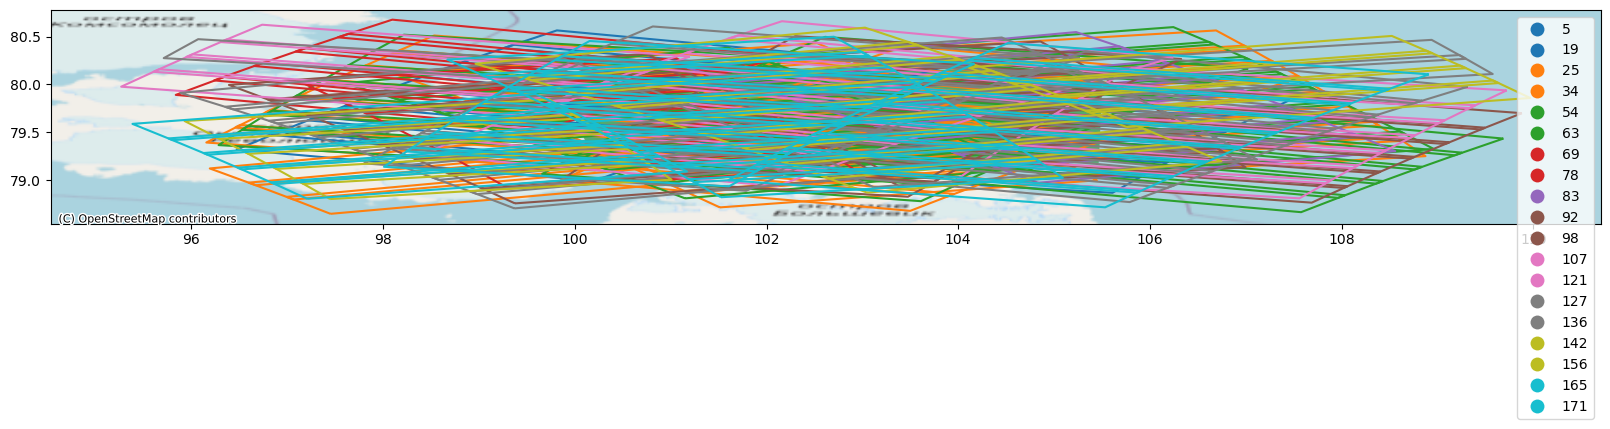

In [23]:
df_mrgs_burst_subset = df_mgrs_burst_f[df_mgrs_burst_f.mgrs_tile_id == tile_id_large_num_tracks].reset_index(drop=True)
burst_ids_subset = df_mrgs_burst_subset.jpl_burst_id.tolist()

df_mgrs_plot = df_mgrs[df_mgrs.mgrs_tile_id == tile_id_large_num_tracks].reset_index(drop=True)
df_burst_plot = df_burst_final[df_burst_final.jpl_burst_id.isin(burst_ids_subset)].reset_index(drop=True)
df_burst_plot.geometry = df_burst_plot.geometry.boundary
fig, ax = plt.subplots(dpi=100, figsize=(20, 20))

df_mgrs_plot.plot(alpha=.5, ax=ax, color='green')
df_burst_plot.plot(alpha=1, ax=ax, column='track_number', categorical=True, legend=True)
ctx.add_basemap(ax,
               crs=df_mgrs_plot.crs.to_string(),
               source=ctx.providers.OpenStreetMap.Mapnik
              )

Remember in these high lattidude areas, these all represent different data takes!

<Axes: >

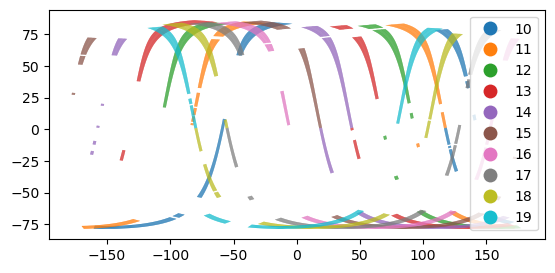

In [24]:
df_burst_final[df_burst_final['track_number'].isin(list(range(10, 20)))].plot(column='track_number', categorical=True, legend=True)

## With a Small Overlapping Burst

In [25]:
mgrs_id_with_small_burst_overlapping = '31QGE'

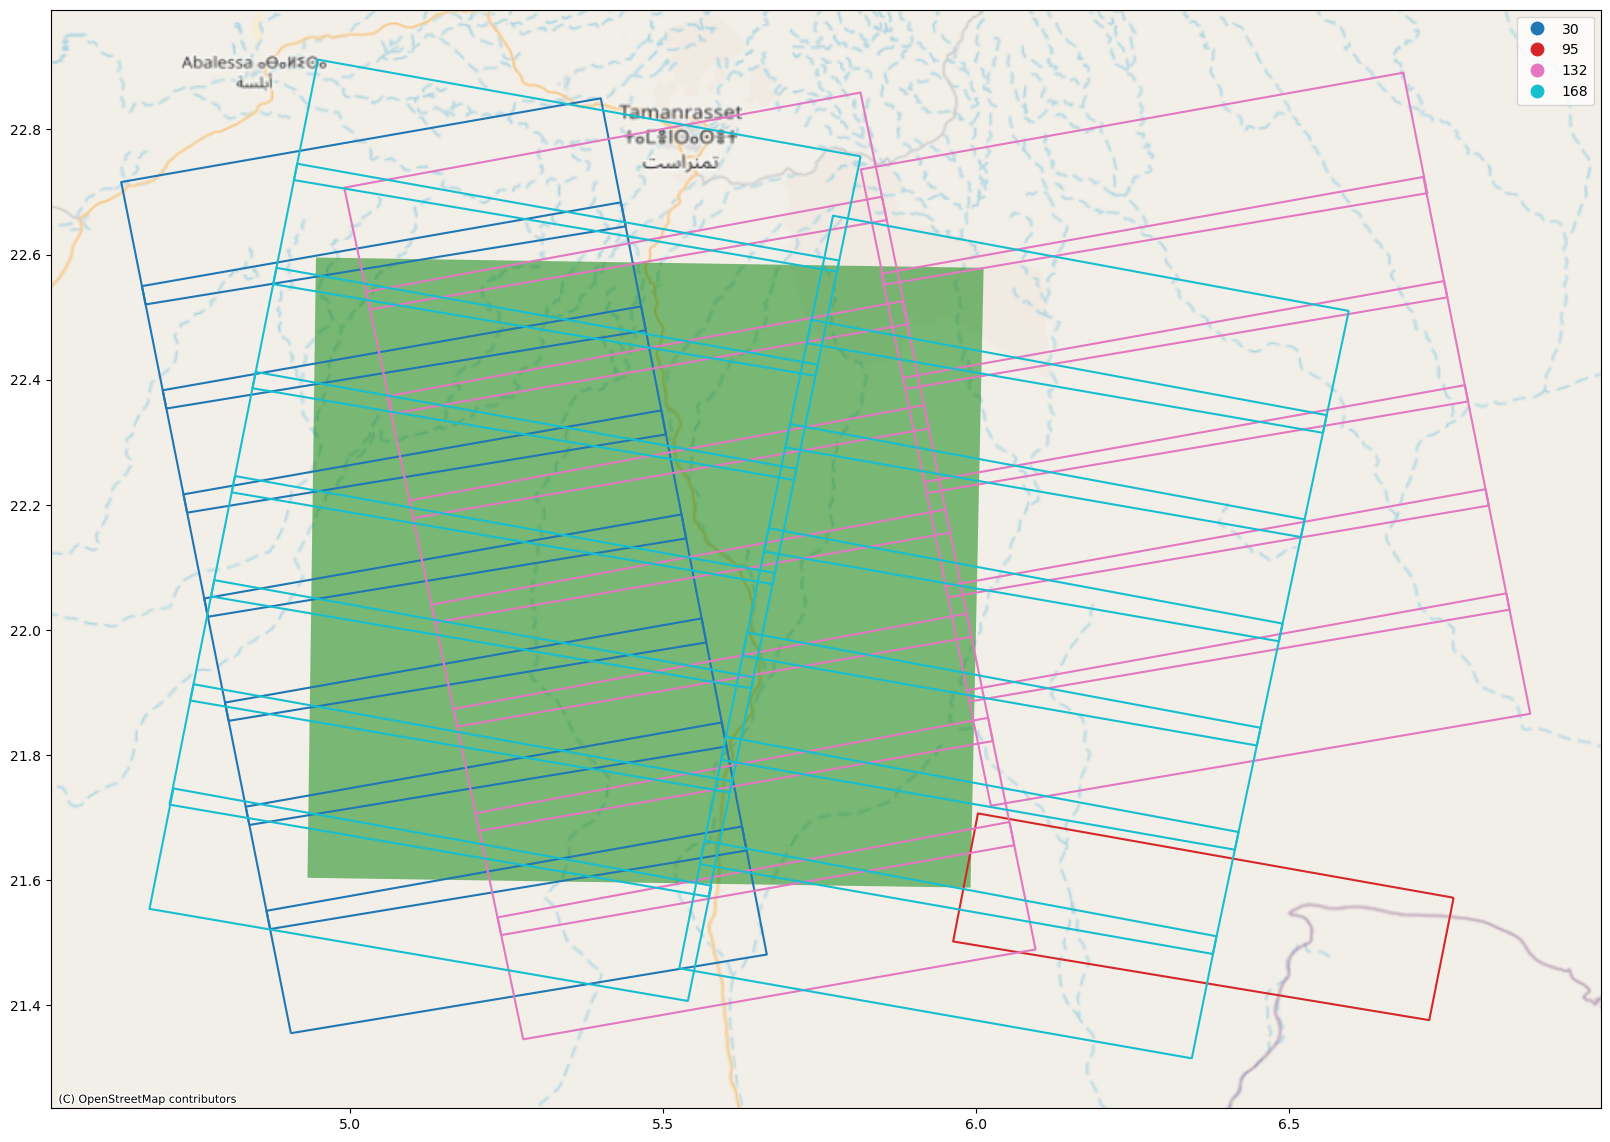

In [26]:
df_mrgs_burst_subset = df_mgrs_burst_f[df_mgrs_burst_f.mgrs_tile_id == mgrs_id_with_small_burst_overlapping].reset_index(drop=True)
burst_ids_subset = df_mrgs_burst_subset.jpl_burst_id.tolist()

df_mgrs_plot = df_mgrs[df_mgrs.mgrs_tile_id == mgrs_id_with_small_burst_overlapping].reset_index(drop=True)
df_burst_plot = df_burst_final[df_burst_final.jpl_burst_id.isin(burst_ids_subset)].reset_index(drop=True)
df_burst_plot.geometry = df_burst_plot.geometry.boundary
fig, ax = plt.subplots(dpi=100, figsize=(20, 20))

df_mgrs_plot.plot(alpha=.5, ax=ax, color='green')
df_burst_plot.plot(alpha=1, ax=ax, column='track_number', categorical=True, legend=True)
ctx.add_basemap(ax,
               crs=df_mgrs_plot.crs.to_string(),
               source=ctx.providers.OpenStreetMap.Mapnik
              )

### Random

In [27]:
random_mgrs_tile_id = df_mgrs_burst_f.mgrs_tile_id.sample(n=1, random_state=40).values[0]
random_mgrs_tile_id

'31REK'

In [28]:
df_mrgs_burst_subset = df_mgrs_burst_f[df_mgrs_burst_f.mgrs_tile_id == random_mgrs_tile_id].reset_index(drop=True)
df_mrgs_burst_subset.head()

,mgrs_tile_id,epsg,utm_wkt,geometry,jpl_burst_id,orbit_pass,track_number
0,31REK,32631,"MULTIPOLYGON(((499980 3000000,499980 2890200,6...","POLYGON ((2.99980 27.12247, 2.99980 26.13108, ...",T066-140537-IW2,DESCENDING,66.0
1,31REK,32631,"MULTIPOLYGON(((499980 3000000,499980 2890200,6...","POLYGON ((2.99980 27.12247, 2.99980 26.13108, ...",T066-140536-IW2,DESCENDING,66.0
2,31REK,32631,"MULTIPOLYGON(((499980 3000000,499980 2890200,6...","POLYGON ((2.99980 27.12247, 2.99980 26.13108, ...",T030-062440-IW2,ASCENDING,30.0
3,31REK,32631,"MULTIPOLYGON(((499980 3000000,499980 2890200,6...","POLYGON ((2.99980 27.12247, 2.99980 26.13108, ...",T066-140537-IW3,DESCENDING,66.0
4,31REK,32631,"MULTIPOLYGON(((499980 3000000,499980 2890200,6...","POLYGON ((2.99980 27.12247, 2.99980 26.13108, ...",T030-062442-IW1,ASCENDING,30.0


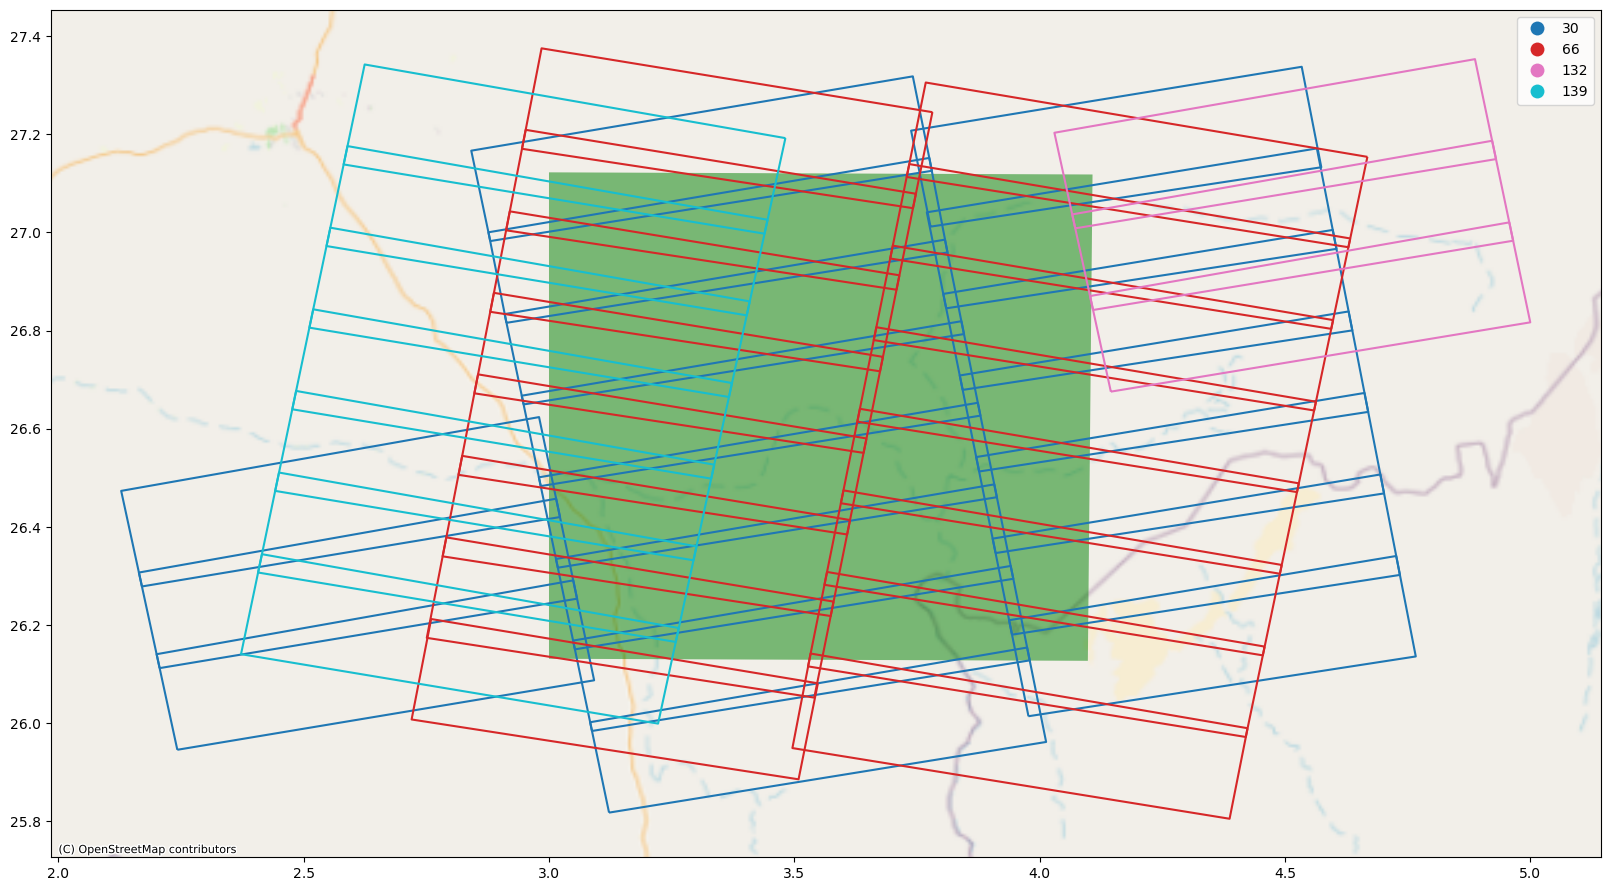

In [29]:
df_mrgs_burst_subset = df_mgrs_burst_f[df_mgrs_burst_f.mgrs_tile_id == random_mgrs_tile_id].reset_index(drop=True)
burst_ids_subset = df_mrgs_burst_subset.jpl_burst_id.tolist()

df_mgrs_plot = df_mgrs[df_mgrs.mgrs_tile_id == random_mgrs_tile_id].reset_index(drop=True)
df_burst_plot = df_burst_final[df_burst_final.jpl_burst_id.isin(burst_ids_subset)].reset_index(drop=True)
df_burst_plot.geometry = df_burst_plot.geometry.boundary
fig, ax = plt.subplots(dpi=100, figsize=(20, 20))

df_mgrs_plot.plot(alpha=.5, ax=ax, color='green')
df_burst_plot.plot(alpha=1, ax=ax, column='track_number', categorical=True, legend=True)
ctx.add_basemap(ax,
               crs=df_mgrs_plot.crs.to_string(),
               source=ctx.providers.OpenStreetMap.Mapnik
              )

### Near Antimeridian

In [30]:
anti_meridian_tile_id = '01VCK'

<Axes: >

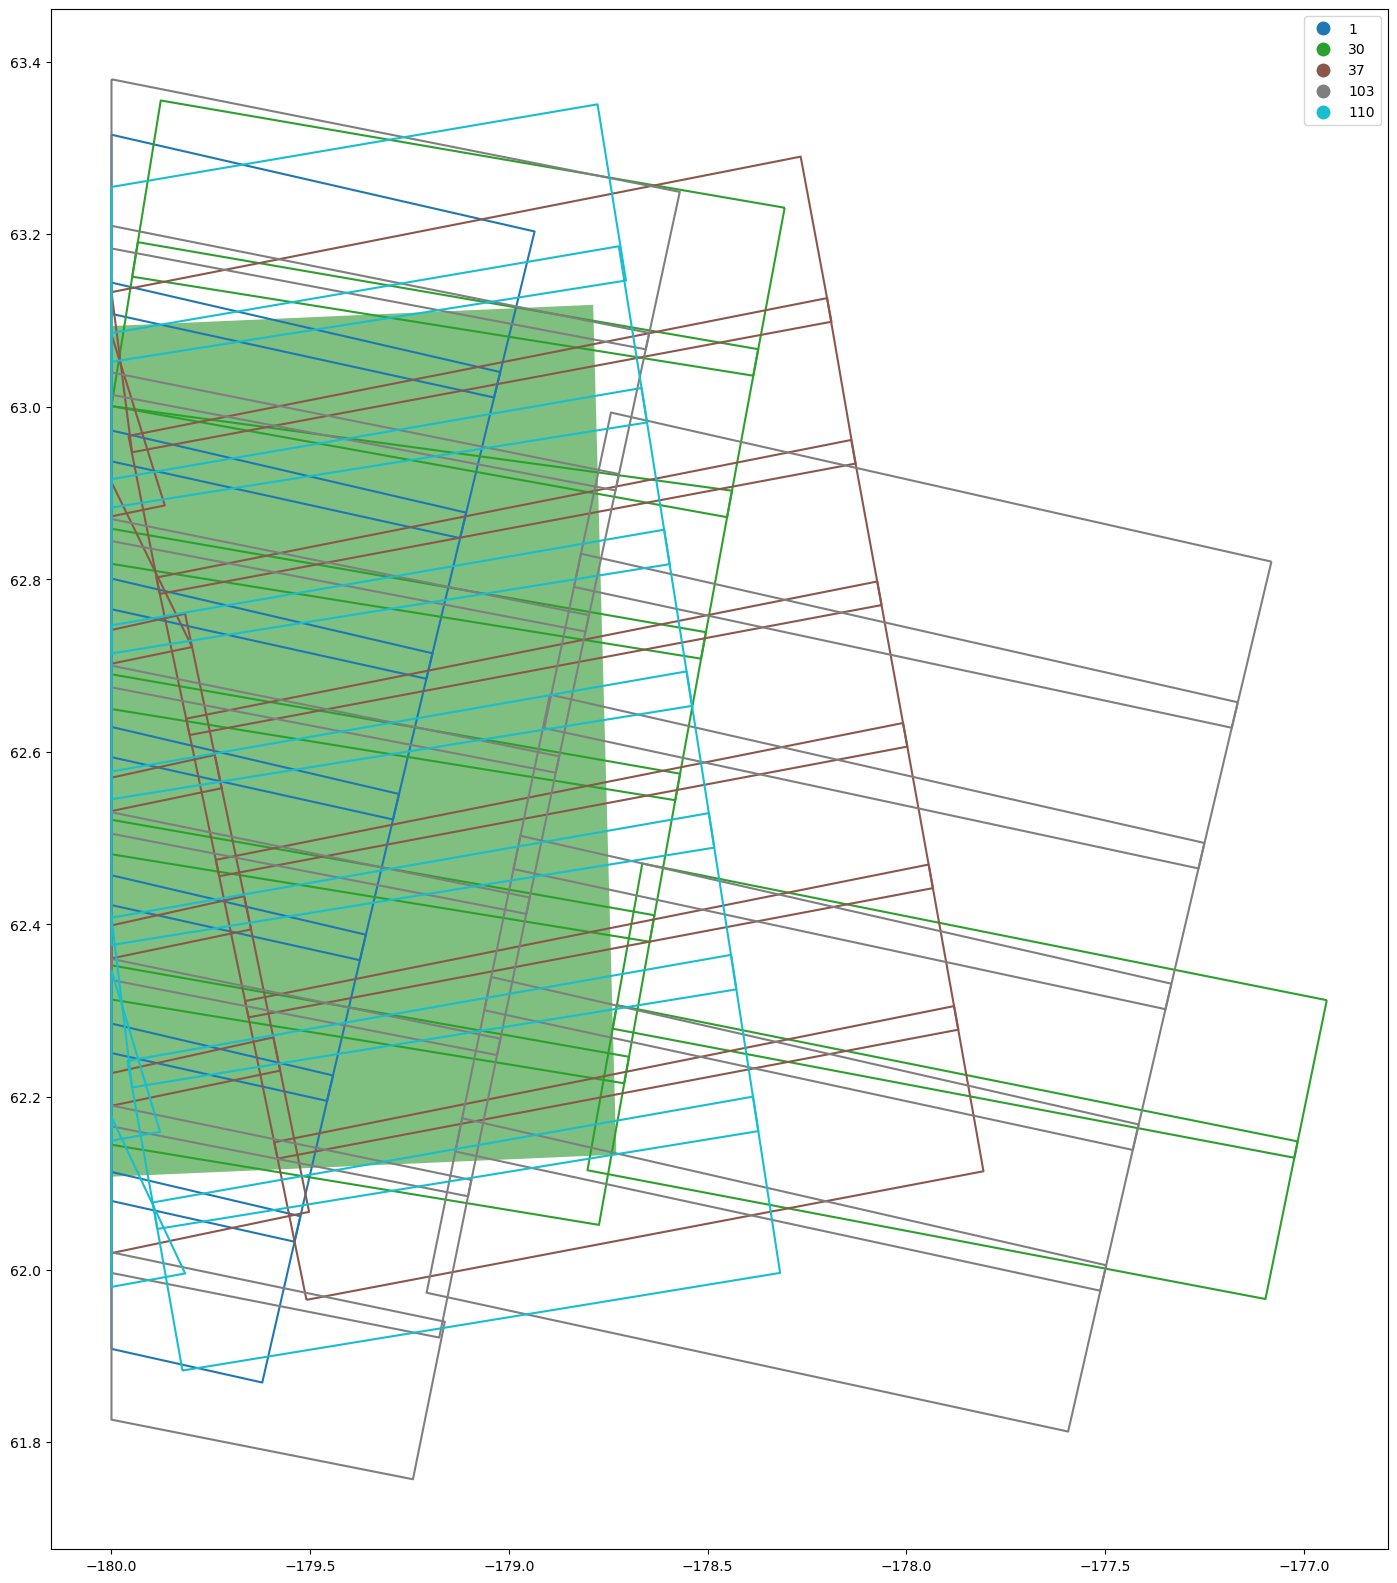

In [31]:
df_mrgs_burst_subset = df_mgrs_burst_f[df_mgrs_burst_f.mgrs_tile_id == anti_meridian_tile_id].reset_index(drop=True)
burst_ids_subset = df_mrgs_burst_subset.jpl_burst_id.tolist()

df_mgrs_plot = df_mgrs[df_mgrs.mgrs_tile_id == anti_meridian_tile_id].explode(ignore_index=True).cx[:0, :].reset_index(drop=True)
df_burst_plot = df_burst_final[df_burst_final.jpl_burst_id.isin(burst_ids_subset)].explode(ignore_index=True).cx[:0, :].reset_index(drop=True)
df_burst_plot.geometry = df_burst_plot.geometry.boundary
fig, ax = plt.subplots(dpi=100, figsize=(20, 20))

df_mgrs_plot.plot(alpha=.5, ax=ax, color='green')
df_burst_plot.plot(alpha=1, ax=ax, column='track_number', categorical=True, legend=True)
# ctx.add_basemap(ax,
#                crs=df_mgrs_plot.crs.to_string(),
#                source=ctx.providers.OpenStreetMap.Mapnik
#               )

### Near Equator

In [32]:
mgrs_tile_id_near_eq = '22NFF'

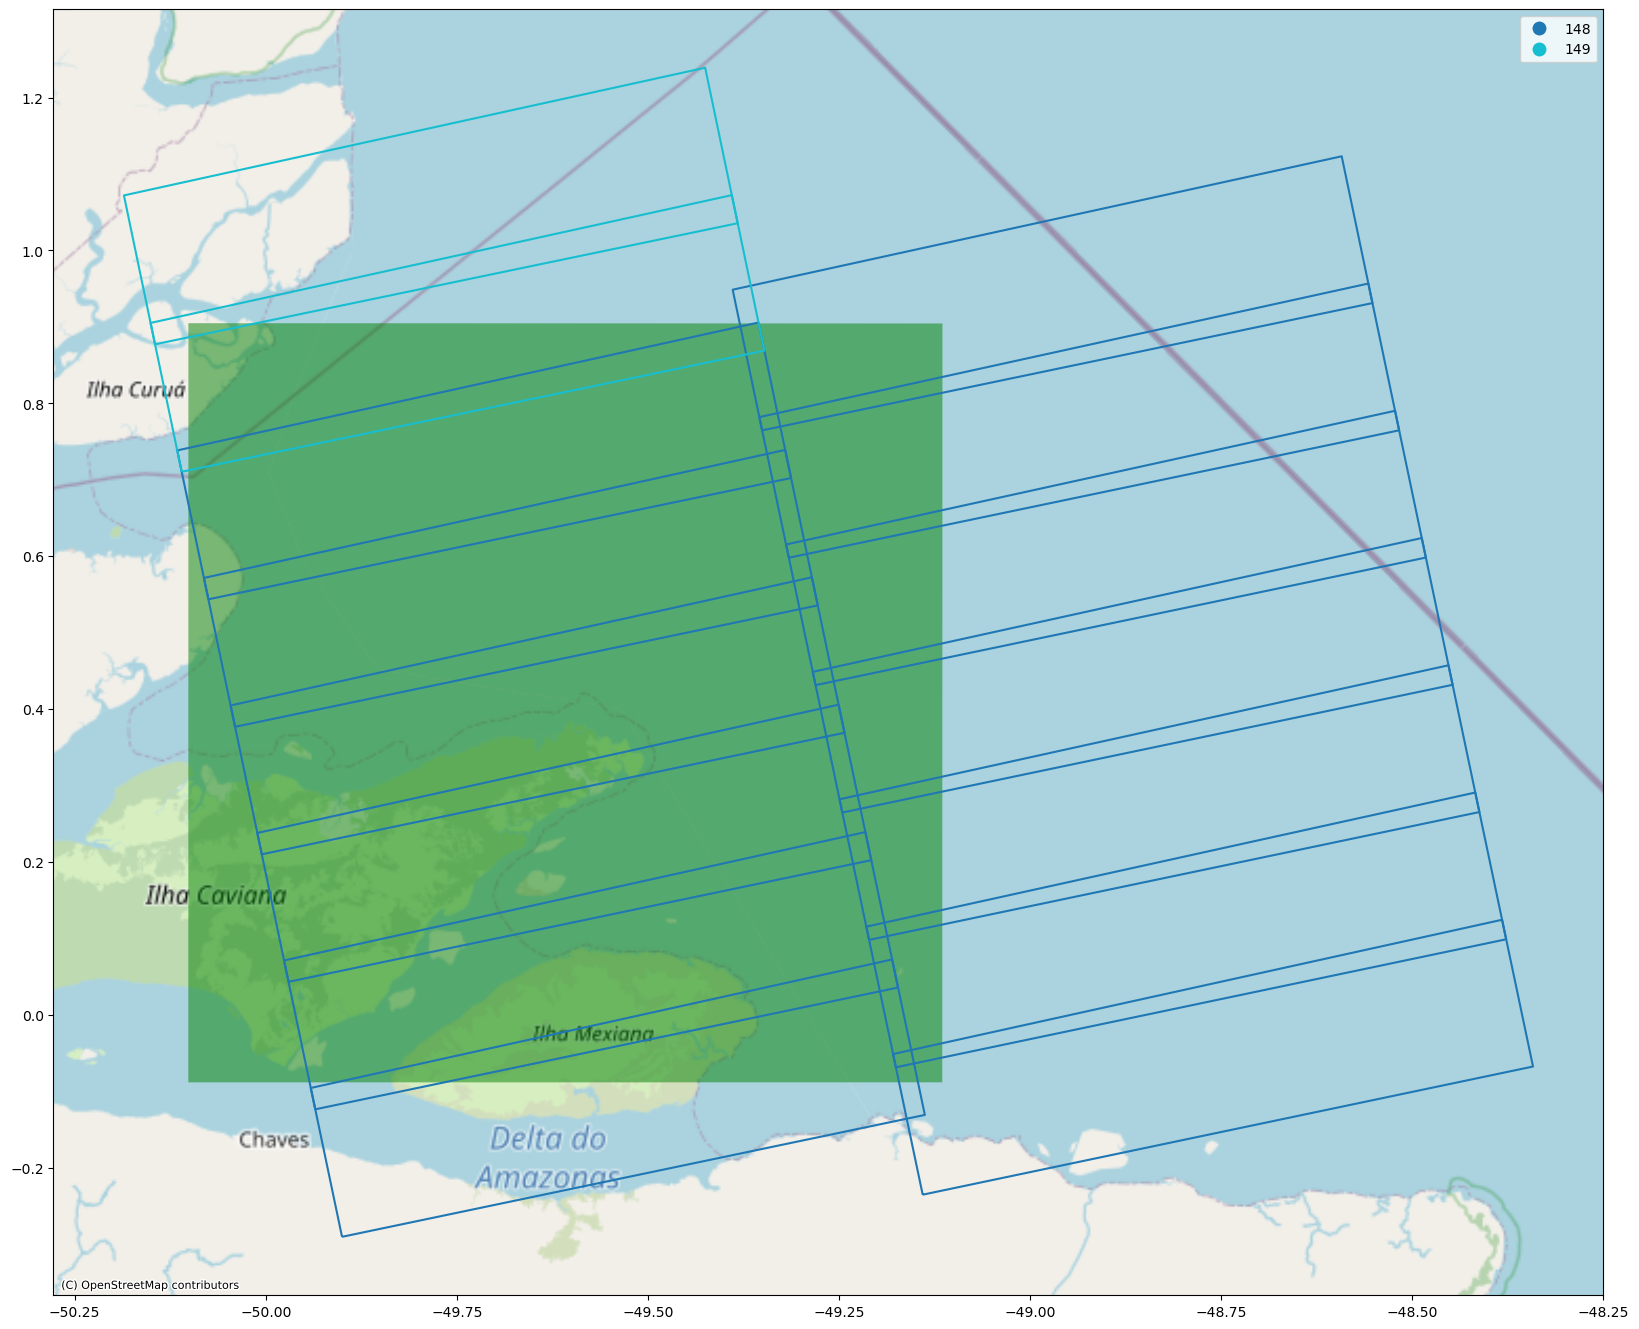

In [33]:
df_mrgs_burst_subset = df_mgrs_burst_f[df_mgrs_burst_f.mgrs_tile_id == mgrs_tile_id_near_eq].reset_index(drop=True)
burst_ids_subset = df_mrgs_burst_subset.jpl_burst_id.tolist()

df_mgrs_plot = df_mgrs[df_mgrs.mgrs_tile_id == mgrs_tile_id_near_eq].reset_index(drop=True)
df_burst_plot = df_burst_final[df_burst_final.jpl_burst_id.isin(burst_ids_subset)].reset_index(drop=True)
df_burst_plot.geometry = df_burst_plot.geometry.boundary
fig, ax = plt.subplots(dpi=100, figsize=(20, 20))
df_burst_plot = df_burst_plot[df_burst_plot.track_number.isin([148, 149])]

df_mgrs_plot.plot(alpha=.5, ax=ax, color='green')
df_burst_plot.plot(alpha=1, ax=ax, column='track_number', categorical=True, legend=True)

ctx.add_basemap(ax,
               crs=df_mgrs_plot.crs.to_string(),
               source=ctx.providers.OpenStreetMap.Mapnik
              )

# MGRS to Track Groups

In [34]:
def group_consecutive_tracks(tracks):
    tracks_sorted = sorted(list(set(tracks)))
    groups = []
    current_group = [tracks_sorted[0]]

    for track in tracks_sorted[1:]:
        if track - current_group[-1] <= 1:
            current_group.append(track)
        else:
            if len(current_group) > 2:
                raise ValueError('Too many tracks in group; should be at most 2')
            groups.append(current_group)
            current_group = [track]
    if current_group:
        if len(current_group) > 2:
            raise ValueError('Too many tracks in group; should be at most 2')
        groups.append(current_group)
    return groups

group_consecutive_tracks([1, 4, 5, 10, 15, 20, 21, 23])

[[1], [4, 5], [10], [15], [20, 21], [23]]

In [35]:
%%time

df_mgrs2track = df_mgrs_burst.groupby('mgrs_tile_id')['track_number'].apply(lambda tracks: list(tracks.unique())).reset_index()
df_mgrs2track.head()

CPU times: user 329 ms, sys: 20.9 ms, total: 350 ms
Wall time: 343 ms


,mgrs_tile_id,track_number
0,01FBE,"[58.0, 154.0, 81.0, 131.0, 52.0]"
1,01FBF,"[58.0, 81.0, 131.0, 154.0]"
2,01GBH,"[81.0, 131.0, 154.0, 29.0]"
3,01GDM,"[58.0, 110.0, 131.0, 37.0]"
4,01GEL,"[58.0, 37.0, 110.0, 160.0]"


In [36]:
df_mgrs2track = pd.merge( df_mgrs[['mgrs_tile_id', 'geometry']], df_mgrs2track)
df_mgrs2track = df_mgrs2track.rename(columns={'track_number': 'track_numbers_all'})
df_mgrs2track.head()

,mgrs_tile_id,geometry,track_numbers_all
0,01FBE,"MULTIPOLYGON (((-179.63379 -49.62222, -179.688...","[58.0, 154.0, 81.0, 131.0, 52.0]"
1,01FBF,"MULTIPOLYGON (((-179.58653 -48.72398, -179.638...","[58.0, 81.0, 131.0, 154.0]"
2,01GBH,"MULTIPOLYGON (((-179.49865 -46.92590, -179.545...","[81.0, 131.0, 154.0, 29.0]"
3,01GDM,"POLYGON ((-178.23431 -43.34619, -178.25485 -44...","[58.0, 110.0, 131.0, 37.0]"
4,01GEL,"POLYGON ((-177.00025 -44.25288, -177.00025 -45...","[58.0, 37.0, 110.0, 160.0]"


In [37]:
df_bounds = df_mgrs2track.bounds
abs_lat = np.abs(df_bounds.miny.values, df_bounds.maxy.values)
df_mgrs2track['abs_lat'] = abs_lat

In [38]:
def track_grouping(row):
    track_numbers = row['track_numbers_all']
    abs_lat = row['abs_lat']
    if abs_lat < 70:
        track_groups = group_consecutive_tracks(track_numbers)
    else:
        track_groups = [[t] for t in sorted(track_numbers)]
    #track_group_strs = ['+'.join([str(s) for s in track_group]) for track_group in track_groups]
    #track_group_str = '_'.join(track_group_strs)
    return track_groups

df_mgrs2track['track_number_groups'] = df_mgrs2track.agg(track_grouping, axis=1)
df_mgrs2track.head()

,mgrs_tile_id,geometry,track_numbers_all,abs_lat,track_number_groups
0,01FBE,"MULTIPOLYGON (((-179.63379 -49.62222, -179.688...","[58.0, 154.0, 81.0, 131.0, 52.0]",50.608678,"[[52.0], [58.0], [81.0], [131.0], [154.0]]"
1,01FBF,"MULTIPOLYGON (((-179.58653 -48.72398, -179.638...","[58.0, 81.0, 131.0, 154.0]",49.710629,"[[58.0], [81.0], [131.0], [154.0]]"
2,01GBH,"MULTIPOLYGON (((-179.49865 -46.92590, -179.545...","[81.0, 131.0, 154.0, 29.0]",47.912929,"[[29.0], [81.0], [131.0], [154.0]]"
3,01GDM,"POLYGON ((-178.23431 -43.34619, -178.25485 -44...","[58.0, 110.0, 131.0, 37.0]",44.341402,"[[37.0], [58.0], [110.0], [131.0]]"
4,01GEL,"POLYGON ((-177.00025 -44.25288, -177.00025 -45...","[58.0, 37.0, 110.0, 160.0]",45.241333,"[[37.0], [58.0], [110.0], [160.0]]"


In [39]:
def group_idxs(groups:list) -> dict:
    out = {track: group_idx for group_idx, group in enumerate(groups) for track in group}
    return out
    
df_mgrs2track['track_number_group_idxs'] = df_mgrs2track.track_number_groups.map(group_idxs)
df_mgrs2track['n_track_groups'] = df_mgrs2track.track_number_groups.map(len)
df_mgrs2track.head()

,mgrs_tile_id,geometry,track_numbers_all,abs_lat,track_number_groups,track_number_group_idxs,n_track_groups
0,01FBE,"MULTIPOLYGON (((-179.63379 -49.62222, -179.688...","[58.0, 154.0, 81.0, 131.0, 52.0]",50.608678,"[[52.0], [58.0], [81.0], [131.0], [154.0]]","{52.0: 0, 58.0: 1, 81.0: 2, 131.0: 3, 154.0: 4}",5
1,01FBF,"MULTIPOLYGON (((-179.58653 -48.72398, -179.638...","[58.0, 81.0, 131.0, 154.0]",49.710629,"[[58.0], [81.0], [131.0], [154.0]]","{58.0: 0, 81.0: 1, 131.0: 2, 154.0: 3}",4
2,01GBH,"MULTIPOLYGON (((-179.49865 -46.92590, -179.545...","[81.0, 131.0, 154.0, 29.0]",47.912929,"[[29.0], [81.0], [131.0], [154.0]]","{29.0: 0, 81.0: 1, 131.0: 2, 154.0: 3}",4
3,01GDM,"POLYGON ((-178.23431 -43.34619, -178.25485 -44...","[58.0, 110.0, 131.0, 37.0]",44.341402,"[[37.0], [58.0], [110.0], [131.0]]","{37.0: 0, 58.0: 1, 110.0: 2, 131.0: 3}",4
4,01GEL,"POLYGON ((-177.00025 -44.25288, -177.00025 -45...","[58.0, 37.0, 110.0, 160.0]",45.241333,"[[37.0], [58.0], [110.0], [160.0]]","{37.0: 0, 58.0: 1, 110.0: 2, 160.0: 3}",4


In [40]:
df_mgrs2track.shape[0] == len(df_mgrs2track.mgrs_tile_id.unique())

True

In [41]:
mgrs2track_group = df_mgrs2track[['mgrs_tile_id', 'track_number_group_idxs']].set_index('mgrs_tile_id').to_dict()['track_number_group_idxs']
#mgrs2track_group

## Update The MGRS/Burst Table

In [42]:
df_mgrs_burst_f.head()

,mgrs_tile_id,epsg,utm_wkt,geometry,jpl_burst_id,orbit_pass,track_number
0,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T058-123817-IW2,DESCENDING,58.0
1,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T058-123816-IW2,DESCENDING,58.0
2,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T154-330467-IW3,ASCENDING,154.0
3,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T058-123815-IW2,DESCENDING,58.0
4,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T081-173673-IW1,ASCENDING,81.0


In [43]:
%%time

def label_acquisition_group(row):
    mgrs_tile = row['mgrs_tile_id']
    track = row['track_number']
    track_group = mgrs2track_group[mgrs_tile][track]
    return track_group

df_mgrs_burst_f['acq_group_id_within_mgrs_tile'] = df_mgrs_burst_f.agg(label_acquisition_group, axis=1)
df_mgrs_burst_f.head()

CPU times: user 3.98 s, sys: 63.6 ms, total: 4.04 s
Wall time: 4.05 s


,mgrs_tile_id,epsg,utm_wkt,geometry,jpl_burst_id,orbit_pass,track_number,acq_group_id_within_mgrs_tile
0,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T058-123817-IW2,DESCENDING,58.0,1
1,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T058-123816-IW2,DESCENDING,58.0,1
2,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T154-330467-IW3,ASCENDING,154.0,4
3,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T058-123815-IW2,DESCENDING,58.0,1
4,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T081-173673-IW1,ASCENDING,81.0,2


In [44]:
df_mgrs_burst_f.shape

(1126910, 8)

# Counting The Number of Passes (i.e. Track Groups) Per MGRS Tile

Text(0, 0.5, 'Frequency')

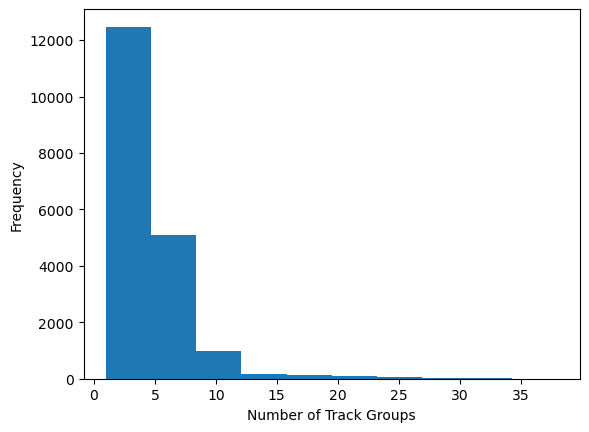

In [45]:
plt.hist(df_mgrs2track.n_track_groups.values)
plt.xlabel('Number of Track Groups')
plt.ylabel('Frequency')

# Calculating Area Per Pass in km${}^2$

In [46]:
df_burst_groups = pd.merge(df_burst_final, 
                           df_mgrs_burst_f[['jpl_burst_id', 'mgrs_tile_id', 'acq_group_id_within_mgrs_tile', 'geometry']], 
                           on='jpl_burst_id', 
                           how='left', 
                           suffixes=('', '_mgrs')
                          )

In [47]:
df_burst_groups.head()

,jpl_burst_id,orbit_pass,track_number,geometry,mgrs_tile_id,acq_group_id_within_mgrs_tile,geometry_mgrs
0,T001-000025-IW1,ASCENDING,1,"POLYGON ((2.53190 4.75701, 3.29631 4.91201, 3....",NaN,NaN,None
1,T001-000025-IW2,ASCENDING,1,"POLYGON ((3.25912 4.97460, 4.06055 5.13657, 4....",NaN,NaN,None
2,T001-000025-IW3,ASCENDING,1,"POLYGON ((4.02659 5.18854, 4.73485 5.32978, 4....",31NFG,0.0,"POLYGON ((3.90412 6.33225, 3.90253 5.33909, 4...."
3,T001-000026-IW1,ASCENDING,1,"POLYGON ((2.49611 4.92361, 3.26087 5.07851, 3....",NaN,NaN,None
4,T001-000026-IW2,ASCENDING,1,"POLYGON ((3.22392 5.14115, 4.02565 5.30297, 3....",31NFG,0.0,"POLYGON ((3.90412 6.33225, 3.90253 5.33909, 4...."


In [48]:
%%time

df_burst_groups_d = df_burst_groups.dissolve(by=['mgrs_tile_id', 'acq_group_id_within_mgrs_tile'], aggfunc='first').reset_index(drop=False)
df_burst_groups_d.head()

CPU times: user 19.3 s, sys: 282 ms, total: 19.6 s
Wall time: 19.8 s


,mgrs_tile_id,acq_group_id_within_mgrs_tile,geometry,jpl_burst_id,orbit_pass,track_number,geometry_mgrs
0,01FBE,0.0,"POLYGON ((179.04464 -50.41252, 178.00046 -50.6...",T052-111377-IW3,ASCENDING,52,"MULTIPOLYGON (((-179.63379 -49.62222, -179.688..."
1,01FBE,1.0,"MULTIPOLYGON (((-179.37891 -50.55099, -179.470...",T058-123812-IW2,DESCENDING,58,"MULTIPOLYGON (((-179.63379 -49.62222, -179.688..."
2,01FBE,2.0,"MULTIPOLYGON (((-180.00000 -50.02605, -180.000...",T081-173673-IW1,ASCENDING,81,"MULTIPOLYGON (((-179.63379 -49.62222, -179.688..."
3,01FBE,3.0,"MULTIPOLYGON (((-179.87576 -50.00608, -179.960...",T131-280608-IW1,DESCENDING,131,"MULTIPOLYGON (((-179.63379 -49.62222, -179.688..."
4,01FBE,4.0,"MULTIPOLYGON (((-179.98057 -50.61035, -179.980...",T154-330465-IW3,ASCENDING,154,"MULTIPOLYGON (((-179.63379 -49.62222, -179.688..."


In [49]:
df_burst_groups_d = df_burst_groups_d[['mgrs_tile_id', 'acq_group_id_within_mgrs_tile', 'geometry', 'geometry_mgrs']]

<Axes: >

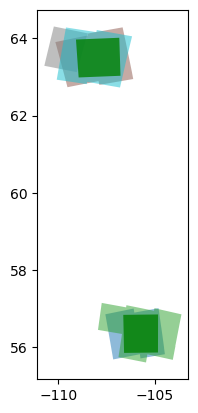

In [50]:
fig, ax = plt.subplots()

K = 10004
df_t = df_burst_groups_d.iloc[K:K + 5].reset_index()
df_t.plot(column='acq_group_id_within_mgrs_tile', categorical=True, ax=ax, alpha=.5)
df_mgrs[df_mgrs.mgrs_tile_id.isin(df_t.mgrs_tile_id.unique().tolist())].plot(ax=ax, alpha=.8, color='green')

In [51]:
geos_l = df_burst_groups_d.geometry.tolist()[:]
geos_r = df_burst_groups_d.geometry_mgrs.tolist()[:]

100%|█| 95928/95928 [00:05<00:00, 18114


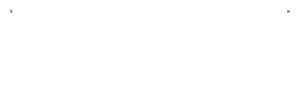

In [52]:
import shapely
from mpire import WorkerPool

with WorkerPool(n_jobs=5, use_dill=True) as pool:
        geos_intersected = pool.map(shapely.intersection, 
                                    zip(geos_l, geos_r),
                                    progress_bar=True, 
                                    progress_bar_style='std', 
                                    iterable_len=len(geos_l),
                                    concatenate_numpy_output=False)
geos_intersected[10]

In [53]:
df_burst_groups_area = gpd.GeoDataFrame(df_burst_groups_d[['mgrs_tile_id', 'acq_group_id_within_mgrs_tile']],
                                        geometry=geos_intersected,
                                        crs=CRS.from_epsg(4326))
df_burst_groups_area.head()

,mgrs_tile_id,acq_group_id_within_mgrs_tile,geometry
0,01FBE,0.0,"POLYGON ((178.77043 -50.48113, 178.80981 -50.0..."
1,01FBE,1.0,"MULTIPOLYGON (((-180.00000 -50.58543, -180.000..."
2,01FBE,2.0,"MULTIPOLYGON (((-180.00000 -49.98781, -180.000..."
3,01FBE,3.0,"MULTIPOLYGON (((-179.96086 -50.16664, -180.000..."
4,01FBE,4.0,"MULTIPOLYGON (((-179.99767 -50.58217, -179.983..."


In [54]:
df_burst_groups_area['area_km2'] = df_burst_groups_area.to_crs('3395')['geometry'].map(lambda p: p.area / 10**6)
df_burst_groups_area.head()

,mgrs_tile_id,acq_group_id_within_mgrs_tile,geometry,area_km2
0,01FBE,0.0,"POLYGON ((178.77043 -50.48113, 178.80981 -50.0...",1169.804908
1,01FBE,1.0,"MULTIPOLYGON (((-180.00000 -50.58543, -180.000...",26418.725295
2,01FBE,2.0,"MULTIPOLYGON (((-180.00000 -49.98781, -180.000...",15240.149300
3,01FBE,3.0,"MULTIPOLYGON (((-179.96086 -50.16664, -180.000...",23261.173999
4,01FBE,4.0,"MULTIPOLYGON (((-179.99767 -50.58217, -179.983...",29044.784347


In [55]:
df_mgrs_burst_f

,mgrs_tile_id,epsg,utm_wkt,geometry,jpl_burst_id,orbit_pass,track_number,acq_group_id_within_mgrs_tile
0,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T058-123817-IW2,DESCENDING,58.0,1
1,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T058-123816-IW2,DESCENDING,58.0,1
2,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T154-330467-IW3,ASCENDING,154.0,4
3,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T058-123815-IW2,DESCENDING,58.0,1
4,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T081-173673-IW1,ASCENDING,81.0,2
...,...,...,...,...,...,...,...,...
1126905,60WWV,32660,"MULTIPOLYGON(((499980 7500000,499980 7390200,6...","POLYGON ((176.99953 67.61553, 176.99955 66.630...",T074-157470-IW1,DESCENDING,74.0,4
1126906,60WWV,32660,"MULTIPOLYGON(((499980 7500000,499980 7390200,6...","POLYGON ((176.99953 67.61553, 176.99955 66.630...",T001-000671-IW2,DESCENDING,1.0,0
1126907,60WWV,32660,"MULTIPOLYGON(((499980 7500000,499980 7390200,6...","POLYGON ((176.99953 67.61553, 176.99955 66.630...",T074-157469-IW1,DESCENDING,74.0,4
1126908,60WWV,32660,"MULTIPOLYGON(((499980 7500000,499980 7390200,6...","POLYGON ((176.99953 67.61553, 176.99955 66.630...",T001-000670-IW2,DESCENDING,1.0,0


In [56]:
df_mgrs_burst_with_area = pd.merge(df_mgrs_burst_f, 
                                   df_burst_groups_area[['mgrs_tile_id', 'acq_group_id_within_mgrs_tile', 'area_km2']],
                                   how='left',
                                   on=['mgrs_tile_id', 'acq_group_id_within_mgrs_tile'])
assert df_mgrs_burst_with_area.shape[0] == df_mgrs_burst_f.shape[0]
df_mgrs_burst_with_area.rename(columns={'area_km2': 'area_per_acq_group_km2'}, inplace=True)
df_mgrs_burst_with_area = df_mgrs_burst_with_area.drop(columns=['epsg', 'utm_wkt', 'geometry'])
df_mgrs_burst_with_area.head()

,mgrs_tile_id,jpl_burst_id,orbit_pass,track_number,acq_group_id_within_mgrs_tile,area_per_acq_group_km2
0,01FBE,T058-123817-IW2,DESCENDING,58.0,1,26418.725295
1,01FBE,T058-123816-IW2,DESCENDING,58.0,1,26418.725295
2,01FBE,T154-330467-IW3,ASCENDING,154.0,4,29044.784347
3,01FBE,T058-123815-IW2,DESCENDING,58.0,1,26418.725295
4,01FBE,T081-173673-IW1,ASCENDING,81.0,2,15240.149300


In [57]:
ind = (df_mgrs_burst_with_area.area_per_acq_group_km2.values < 100)
(ind).sum()

4001

# Append Burst Count Per MGRS Tile and Data-take

In [58]:
group = ['mgrs_tile_id', 'acq_group_id_within_mgrs_tile']
df_counts = df_mgrs_burst_with_area.groupby(group).size().reset_index(name='n_bursts_per_acq_group')
df_counts.head()

,mgrs_tile_id,acq_group_id_within_mgrs_tile,n_bursts_per_acq_group
0,01FBE,0,3
1,01FBE,1,12
2,01FBE,2,8
3,01FBE,3,14
4,01FBE,4,16


In [59]:
df_mgrs_burst_filtered_with_counts = pd.merge(df_mgrs_burst_with_area, df_counts, how='left', on=group)
df_mgrs_burst_filtered_with_counts.head()

,mgrs_tile_id,jpl_burst_id,orbit_pass,track_number,acq_group_id_within_mgrs_tile,area_per_acq_group_km2,n_bursts_per_acq_group
0,01FBE,T058-123817-IW2,DESCENDING,58.0,1,26418.725295,12
1,01FBE,T058-123816-IW2,DESCENDING,58.0,1,26418.725295,12
2,01FBE,T154-330467-IW3,ASCENDING,154.0,4,29044.784347,16
3,01FBE,T058-123815-IW2,DESCENDING,58.0,1,26418.725295,12
4,01FBE,T081-173673-IW1,ASCENDING,81.0,2,15240.149300,8


# Filtering by Area and number of bursts

In [60]:
ind_area = df_mgrs_burst_filtered_with_counts.area_per_acq_group_km2 > 100
ind_burst = df_mgrs_burst_filtered_with_counts.n_bursts_per_acq_group >= 3

df_mgrs_burst_final = df_mgrs_burst_filtered_with_counts[ind_area & ind_burst].reset_index(drop=True)
df_mgrs_burst_final.shape

(1121381, 7)

In [72]:
df_mgrs_burst_final.track_number = df_mgrs_burst_final.track_number.astype(int)
df_mgrs_burst_final.area_per_acq_group_km2 = df_mgrs_burst_final.area_per_acq_group_km2.astype(int)

df_mgrs_burst_final = df_mgrs_burst_final.sort_values(by=['mgrs_tile_id', 'jpl_burst_id', 'acq_group_id_within_mgrs_tile']).reset_index(drop=True)
df_mgrs_burst_final.head(10)

,mgrs_tile_id,jpl_burst_id,orbit_pass,track_number,acq_group_id_within_mgrs_tile,area_per_acq_group_km2,n_bursts_per_acq_group
0,01FBE,T052-111377-IW3,ASCENDING,52,0,1169,3
1,01FBE,T052-111378-IW3,ASCENDING,52,0,1169,3
2,01FBE,T052-111379-IW3,ASCENDING,52,0,1169,3
3,01FBE,T058-123812-IW2,DESCENDING,58,1,26418,12
4,01FBE,T058-123812-IW3,DESCENDING,58,1,26418,12
5,01FBE,T058-123813-IW2,DESCENDING,58,1,26418,12
6,01FBE,T058-123813-IW3,DESCENDING,58,1,26418,12
7,01FBE,T058-123814-IW2,DESCENDING,58,1,26418,12
8,01FBE,T058-123814-IW3,DESCENDING,58,1,26418,12
9,01FBE,T058-123815-IW2,DESCENDING,58,1,26418,12


In [77]:
df_mgrs_burst_final.to_parquet('mgrs_burst_lookup_table.parquet', compression='zstd')

# Serializing Burst data

In [78]:
df_burst_final.shape

(527241, 4)

In [79]:
dist_s1_bursts = df_mgrs_burst_final.jpl_burst_id.unique().tolist()
df_burst_final_dist_s1 = df_burst_final[df_burst_final.jpl_burst_id.isin(dist_s1_bursts)][['jpl_burst_id', 'geometry']].reset_index(drop=True)
df_burst_final_dist_s1.shape

(383980, 2)

In [80]:
df_burst_final_dist_s1.to_parquet('jpl_burst_geo.parquet', compression='zstd')
df_burst_final_dist_s1.head()

,jpl_burst_id,geometry
0,T001-000025-IW3,"POLYGON ((4.02659 5.18854, 4.73485 5.32978, 4...."
1,T001-000026-IW2,"POLYGON ((3.22392 5.14115, 4.02565 5.30297, 3...."
2,T001-000026-IW3,"POLYGON ((3.99185 5.35497, 4.70037 5.49605, 4...."
3,T001-000027-IW1,"POLYGON ((2.46164 5.09047, 3.22658 5.24523, 3...."
4,T001-000027-IW2,"POLYGON ((3.18963 5.30788, 3.99158 5.46953, 3...."
